# AI-Powered Phishing Email Detection

## Data Loading and Exploration

This section loads and inspects two datasets:
- Enron dataset (legitimate emails)
- EduPhish dataset (phishing emails)

The goal is to understand the structure of both datasets before preprocessing and merging them into a unified format for machine learning.

## Load Enron Dataset (Legitimate Emails)

The Enron dataset contains real corporate emails. This dataset will be used to represent legitimate (non-phishing) email examples.

In [62]:
import pandas as pd

enron_df = pd.read_csv("../data/raw/enron_data_fraud_labeled.csv")

print(enron_df.head())
print(enron_df.columns)


/var/folders/fw/4swmk_ms2mng4kj84x7kpsj80000gn/T/ipykernel_2080/1102957717.py:3: DtypeWarning: Columns (0: Mime-Version, 1: X-bcc) have mixed types. Specify dtype option on import or set low_memory=False.
  enron_df = pd.read_csv("../data/raw/enron_data_fraud_labeled.csv")


  Folder-User Folder-Name                                     Message-ID  \
0     maildir    arnold-j  <17334447.1075857585446.JavaMail.evans@thyme>   
1     maildir    arnold-j  <19171686.1075857585034.JavaMail.evans@thyme>   
2     maildir    arnold-j  <29887033.1075857630725.JavaMail.evans@thyme>   
3     maildir    arnold-j   <2526360.1075857584903.JavaMail.evans@thyme>   
4     maildir    arnold-j  <30102065.1075857630952.JavaMail.evans@thyme>   

                                    Date                     From  \
0  Thu, 16 Nov 2000 09:30:00 -0800 (PST)          msagel@home.com   
1   Fri, 8 Dec 2000 05:05:00 -0800 (PST)  slafontaine@globalp.com   
2  Tue, 15 May 2001 09:43:00 -0700 (PDT)  iceoperations@intcx.com   
3  Mon, 11 Dec 2000 23:52:00 -0800 (PST)       klarnold@flash.net   
4  Mon, 14 May 2001 23:59:00 -0700 (PDT)    soblander@carrfut.com   

                                                  To  \
0                                  jarnold@enron.com   
1               

## Load Phishing Dataset

The EduPhish dataset contains phishing email examples. This dataset will be used to represent malicious email content.

In [63]:
phishing_df = pd.read_csv("../data/raw/eduphish_dataset.csv")

print(phishing_df.head())
print(phishing_df.columns)

                                                text  label
0  Aiming to be as ANSI C compatible as possible ...      0
1  career opportunity dear mr . kaminski ,\r\n?\r...      0
2  Start Date: 12/16/01; HourAhead hour: 1;  No a...      0
3  Reservation status has changed to RECEIVED. Se...      0
4  Market Watch News Flash\nWe are following the ...      1
Index(['text', 'label'], dtype='str')


## Dataset Inspection

The structure of both datasets is examined to identify:
- The column containing email text
- The column containing labels (if available)

This step is essential before preprocessing and merging.

In [64]:
print("ENRON COLUMNS:")
print(enron_df.columns)

print("\nPHISHING COLUMNS:")
print(phishing_df.columns)

ENRON COLUMNS:
Index(['Folder-User', 'Folder-Name', 'Message-ID', 'Date', 'From', 'To',
       'Subject', 'Mime-Version', 'Content-Type', 'Content-Transfer-Encoding',
       'X-From', 'X-To', 'X-cc', 'X-bcc', 'X-Folder', 'X-Origin', 'X-FileName',
       'Body', 'Cc', 'Bcc', 'Time', 'Attendees', 'Re', 'Source', 'Mail-ID',
       'POI-Present', 'Suspicious-Folders', 'Sender-Type',
       'Unique-Mails-From-Sender', 'Low-Comm', 'Contains-Reply-Forwards',
       'Label'],
      dtype='str')

PHISHING COLUMNS:
Index(['text', 'label'], dtype='str')


## Data Preprocessing and Standardisation

Both datasets use different column names for email content and labels.
To prepare the data for machine learning, the datasets are standardised into a common format:

- `text` → email content  
- `label` → classification (0 = legitimate, 1 = phishing)

The datasets are then merged into a single dataframe.

In [65]:
# --- Select relevant columns ---

# Enron: rename Body → text, Label → label
enron_clean = enron_df[['Body', 'Label']].copy()
enron_clean.columns = ['text', 'label']

# Phishing: already correct format
phishing_clean = phishing_df[['text', 'label']].copy()

# --- Combine datasets ---
combined_df = pd.concat([enron_clean, phishing_clean], ignore_index=True)

# --- Clean data ---
combined_df = combined_df.dropna()

# --- Check result ---
print(combined_df.head())
print("\nDataset shape:", combined_df.shape)
print("\nClass distribution:\n", combined_df['label'].value_counts())

                                                text  label
0  Status John: I'm not really sure what happened...      0
1  re:summer inverses i suck-hope youve made more...      0
2  The WTI Bullet swap contracts Hi, Following th...      0
3  Fwd: NYTimes.com Article: Suspended Rabbi Quit...      0
4  daily charts and matrices as hot links 5/15 Th...      0

Dataset shape: (464359, 2)

Class distribution:
 label
0    454215
1     10144
Name: count, dtype: int64


In [66]:
combined_df['label'].value_counts()

label
0    454215
1     10144
Name: count, dtype: int64

## Handling Class Imbalance

The dataset is highly imbalanced, with significantly more legitimate emails than phishing emails.

To prevent the model from being biased towards the majority class, the dataset is balanced by undersampling the legitimate emails to match the number of phishing samples.

In [67]:
# Separate classes
legit = combined_df[combined_df['label'] == 0]
phishing = combined_df[combined_df['label'] == 1]

# Undersample legitimate emails
legit_sample = legit.sample(n=len(phishing), random_state=42)

# Combine balanced dataset
balanced_df = pd.concat([legit_sample, phishing])

# Shuffle dataset
balanced_df = balanced_df.sample(frac=1, random_state=42)

# Check new distribution
print(balanced_df['label'].value_counts())

label
1    10144
0    10144
Name: count, dtype: int64


## Step 1: Text Preprocessing

In this step, the balanced email dataset is cleaned to improve consistency before feature extraction.

The purpose of preprocessing is to reduce noise in the email text while preserving security-relevant indicators that may help distinguish phishing from legitimate messages. Examples of useful indicators include suspicious links, email addresses, urgency language, and patterns involving credentials or payment requests.

This preprocessing strategy is intentionally conservative. It removes formatting artifacts such as HTML tags and extra whitespace, while preserving the semantic structure of the email content. Aggressive preprocessing techniques such as stemming or extensive stopword removal are avoided at this stage because they may remove contextual signals important for phishing detection.

The output of this stage is a cleaned text column that will later be transformed using TF-IDF vectorization for the baseline machine learning model.

In [68]:
import re
import html
import numpy as np


---

## 2. Inspect Dataset

```markdown
### Inspect Balanced Dataset

Before preprocessing, the dataset is inspected to confirm its structure and class distribution.


In [69]:
print("Balanced dataset shape:", balanced_df.shape)
print("\nClass distribution:")
print(balanced_df["label"].value_counts())

balanced_df.head()

Balanced dataset shape: (20288, 2)

Class distribution:
label
1    10144
0    10144
Name: count, dtype: int64


,text,label
43456,Rates DROPPED! Low Interest Loans From Aggress...,1
78986,"Lisa Fawcett has invited you to ""A Premier Des...",1
453785,-------------------------\n-------------------...,1
207852,"All: In follow-up to my previous note, enclose...",0
464237,---------------------------------\n-----------...,1



---

## 3. Preprocessing Function

```markdown
### Define Preprocessing Function

A preprocessing function is defined to clean email text while preserving important phishing indicators such as URLs and email addresses.

Safely preprocess email text for phishing detection.
    
Steps:
    1. Convert to string
    2. Decode HTML entities
    3. Remove HTML tags
    4. Replace URLs with a placeholder
    5. Replace email addresses with a placeholder
    6. Replace numbers with a placeholder
    7. Lowercase text
    8. Remove extra whitespace
    
This approach is conservative to preserve phishing-related signals.


In [70]:
def preprocess_email_text(text):

    
    # Ensure input is string
    text = str(text)
    
    # Decode HTML entities (&amp;, &lt;, etc.)
    text = html.unescape(text)
    
    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)
    
    # Replace URLs with placeholder
    text = re.sub(r"(http[s]?://\S+|www\.\S+)", " URLTOKEN ", text)
    
    # Replace email addresses with placeholder
    text = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " EMAILTOKEN ", text)
    
    # Replace numbers with placeholder
    text = re.sub(r"\b\d+\b", " NUMTOKEN ", text)
    
    # Lowercase
    text = text.lower()
    
    # Remove excessive repeated punctuation (optional light cleanup)
    text = re.sub(r"([!?.,])\1{1,}", r"\1", text)
    
    # Keep only basic word characters and selected punctuation
    # This avoids strange symbols while preserving some sentence structure
    text = re.sub(r"[^a-z0-9\s!?.,:_-]", " ", text)
    
    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


---

## 4. Apply Preprocessing


### Apply Preprocessing

The preprocessing function is applied to all email texts to create a cleaned version of the dataset.



In [71]:
balanced_df = balanced_df.copy()
balanced_df["clean_text"] = balanced_df["text"].apply(preprocess_email_text)


---

## 5. Compare Before and After

```markdown
### Compare Original and Cleaned Text

A sample of emails is inspected before and after preprocessing to ensure that important information is preserved.



In [72]:
sample_indices = balanced_df.sample(5, random_state=42).index

for idx in sample_indices:
    print("=" * 100)
    print("ORIGINAL TEXT:\n")
    print(balanced_df.loc[idx, "text"][:1000])
    print("\nCLEANED TEXT:\n")
    print(balanced_df.loc[idx, "clean_text"][:1000])
    print("\nLABEL:", balanced_df.loc[idx, "label"])

ORIGINAL TEXT:

GRAND UNIVERSAL PROMO
FROM: THE DESK OF THE DIRECTOR PROMOTIONS,
INTERNATIONAL PROMOTIONS/PRIZE AWARD DEPARTMENT,
3b Olympic Way, Sefton Business Park,
Aintree, Liverpool , L30 1RD

REF: GUPL/74-A0802742005


                          AWARD NOTIFICATION; FINAL NOTICE

We are pleased to inform you of the announcement today, of winners of the 
GRAND UNIVERSAL PROMO held on 28th of February 2005.

Your email address was attached to ticket number 22-1356-4096-988; with 
serial number A)69-07 drew the lucky numbers 09-23-13-56-80-40, and 
consequently won in category A. You have therefore been approved for a lump 
sum pay out of GBP 1,400,000.00 POUNDS in cash credited to file REF 
GUPL/74-A0802742005 This is from total prize money of GBP 7,000,000.00 
POUNDS, shared among the Five (5) international winners in this category.


All participants were selected through a computer ballot system drawn from 
100,000 companies/individuals from Middle East, Australia, New Zealand, 
A


---

## 6. Quality Checks

```markdown
### Data Quality Checks

This step verifies that no null or empty values were introduced during preprocessing. A small number of emails (40 instances) became empty after preprocessing. These were likely messages containing only formatting artifacts or non-informative content. Such samples were removed to ensure meaningful feature extraction and improve model quality.


In [73]:
print("Missing values in clean_text:", balanced_df["clean_text"].isnull().sum())
print("Empty strings in clean_text:", (balanced_df["clean_text"].str.strip() == "").sum())

balanced_df[["text", "clean_text", "label"]].head()

Missing values in clean_text: 0
Empty strings in clean_text: 40


,text,clean_text,label
43456,Rates DROPPED! Low Interest Loans From Aggress...,rates dropped! low interest loans from aggress...,1
78986,"Lisa Fawcett has invited you to ""A Premier Des...",lisa fawcett has invited you to a premier desi...,1
453785,-------------------------\n-------------------...,------------------------- --------------------...,1
207852,"All: In follow-up to my previous note, enclose...","all: in follow-up to my previous note, enclose...",0
464237,---------------------------------\n-----------...,--------------------------------- ------------...,1


In [74]:
balanced_df = balanced_df[balanced_df["clean_text"].str.strip() != ""]

In [75]:
print("Empty strings after removal:",
      (balanced_df["clean_text"].str.strip() == "").sum())

Empty strings after removal: 0



---

## 7. Text Length Analysis

```markdown
### Text Length Analysis

Text lengths before and after preprocessing are compared to ensure that important content has not been excessively removed.

Key conclusions: 
-Very small change in average length
-Original mean: ~2571 characters
-Cleaned mean: ~2526 characters
-Only a slight reduction, meaning preprocessing did not remove much content

Median and quartiles are nearly identical:
-This shows that for most emails, the structure and amount of text stayed almost unchanged

Maximum lengths are still very large:
-Indicates that long emails remain long after cleaning
-No aggressive truncation or loss of large documents

Some empty cleaned texts (40 cases):
-A small number of emails became empty after cleaning
-Likely emails that originally contained mostly noise (e.g., symbols, formatting, separators)



In [76]:
balanced_df["original_length"] = balanced_df["text"].astype(str).apply(len)
balanced_df["clean_length"] = balanced_df["clean_text"].astype(str).apply(len)

print(balanced_df[["original_length", "clean_length"]].describe())

       original_length  clean_length
count     2.024800e+04  2.024800e+04
mean      2.576952e+03  2.531825e+03
std       3.357132e+04  3.458574e+04
min       2.000000e+00  2.000000e+00
25%       2.230000e+02  2.460000e+02
50%       7.795000e+02  7.910000e+02
75%       2.624250e+03  2.627500e+03
max       4.600488e+06  4.822510e+06


### Preprocessing Validation

After preprocessing, the cleaned text should remain readable and retain important phishing-related indicators such as links, structure, and suspicious wording. Validation is necessary to ensure that the cleaning process does not unintentionally remove important semantic or security-relevant information.

Manual inspection of sample emails is used to confirm that:
- HTML noise has been removed,
- URLs and email addresses have been normalised,
- text has been standardised to lowercase,
- content remains meaningful for classification.

This validation step helps reduce preprocessing errors before feature extraction and model training.


---

## 8. Clean Final Dataset

```markdown
### Prepare Final Dataset

Temporary columns used for validation are removed to maintain a clean dataset structure.


In [77]:
balanced_df = balanced_df[["text", "clean_text", "label"]]
balanced_df.head()

,text,clean_text,label
43456,Rates DROPPED! Low Interest Loans From Aggress...,rates dropped! low interest loans from aggress...,1
78986,"Lisa Fawcett has invited you to ""A Premier Des...",lisa fawcett has invited you to a premier desi...,1
453785,-------------------------\n-------------------...,------------------------- --------------------...,1
207852,"All: In follow-up to my previous note, enclose...","all: in follow-up to my previous note, enclose...",0
464237,---------------------------------\n-----------...,--------------------------------- ------------...,1



---

## 9. Save Processed Dataset

```markdown
### Save Processed Dataset

The cleaned dataset is saved for reuse in later stages such as feature extraction and model training.


In [78]:
from pathlib import Path

base_dir = Path.cwd().parent 
processed_path = base_dir / "data" / "processed" / "balanced_cleaned_emails.csv"

balanced_df.to_csv(processed_path, index=False)


---

## 10. Train-Test Split

```markdown
### Train-Test Split

The dataset is split into training and testing subsets. Stratified sampling is used to maintain class balance.



In [79]:
from sklearn.model_selection import train_test_split

X = balanced_df["clean_text"]
y = balanced_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

print("\nTraining label distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))

Training set size: 16198
Test set size: 4050

Training label distribution:
label
1    0.500988
0    0.499012
Name: proportion, dtype: float64

Test label distribution:
label
1    0.500988
0    0.499012
Name: proportion, dtype: float64


## Step 3: TF-IDF Feature Extraction

After preprocessing and train-test splitting, the cleaned email text is converted into numerical features using Term Frequency-Inverse Document Frequency (TF-IDF).

TF-IDF is a common feature extraction technique in text classification. It represents each document as a weighted vector based on the importance of words in that document relative to the full corpus. Words that occur frequently in one email but are less common across the dataset receive higher importance.

This method is appropriate for the baseline phishing detection model because it is computationally efficient, interpretable, and widely used in machine learning-based text classification.

To avoid data leakage, the TF-IDF vectorizer is fitted only on the training data and then applied to both the training and test sets.

In [80]:
from sklearn.feature_extraction.text import TfidfVectorizer

### Define TF-IDF Vectorizer

The TF-IDF vectorizer is configured to capture both unigram and bigram features. This allows the model to learn from individual words as well as short phrases such as “verify account” or “click here”, which may be useful indicators of phishing behaviour.

Feature limits are applied to reduce noise and improve computational efficiency.

In [81]:
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    min_df=2,
    max_df=0.95
)

In [82]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (16198, 10000)
X_test_tfidf shape: (4050, 10000)


### Inspect Feature Space

After vectorization, the dimensionality of the training and test feature matrices is checked to confirm that the transformation has been applied correctly.

The number of rows corresponds to the number of email samples, while the number of columns represents the learned TF-IDF features.

In [83]:
feature_names = tfidf_vectorizer.get_feature_names_out()

print("Number of TF-IDF features:", len(feature_names))
print("\nSample features:")
print(feature_names[:30])

Number of TF-IDF features: 10000

Sample features:
['00pm' '0x0' '0x00' '0x01' '0x02' '0x03' '0x04' '0x05' '0x06' '0x07'
 '0x08' '0x09' '0x1' '0x10' '0x11' '0x12' '0x13' '0x14' '0x15' '0x16'
 '0x17' '0x18' '0x19' '0x2' '0x20' '0x21' '0x22' '0x23' '0x24' '0x25']


## Step 4: Train Logistic Regression Baseline

A Logistic Regression classifier is trained using the TF-IDF feature representation.

Logistic Regression is selected as the first baseline model because it is widely used in text classification, computationally efficient, and relatively interpretable. It provides a strong traditional machine learning benchmark against which more advanced transformer-based models can later be compared.

This baseline model helps establish a reference level of performance for phishing email detection using sparse text features.

In [84]:
from sklearn.linear_model import LogisticRegression

In [85]:
log_reg_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

### Train the Model

The Logistic Regression model is fitted using the TF-IDF-transformed training data.

In [86]:
log_reg_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [87]:
y_pred = log_reg_model.predict(X_test_tfidf)
y_prob = log_reg_model.predict_proba(X_test_tfidf)[:, 1]

## Step 5: Model Evaluation

The baseline model is evaluated using multiple classification metrics.

Accuracy alone is not sufficient for phishing detection because the practical consequences of different error types are not equal. A false negative means a phishing email is incorrectly classified as legitimate, which may expose users to security risks. A false positive means a legitimate email is incorrectly flagged as phishing, which may disrupt normal communication.

For this reason, the evaluation includes:
- Precision
- Recall
- F1-score
- Confusion Matrix

These metrics provide a more complete assessment of the classifier’s effectiveness.

In [88]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [89]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression Results")
print("-" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Logistic Regression Results
----------------------------------------
Accuracy : 0.9541
Precision: 0.9546
Recall   : 0.9537
F1-score : 0.9541


In [90]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Legitimate", "Phishing"]))

Classification Report:

              precision    recall  f1-score   support

  Legitimate       0.95      0.95      0.95      2021
    Phishing       0.95      0.95      0.95      2029

    accuracy                           0.95      4050
   macro avg       0.95      0.95      0.95      4050
weighted avg       0.95      0.95      0.95      4050



### Classification Report

The classification report provides a detailed breakdown of model performance for each class. It is especially useful for understanding whether the classifier performs equally well on both legitimate and phishing emails. The baseline Logistic Regression model achieved an F1-score of 0.95 for both legitimate and phishing classes, indicating strong and balanced classification performance. Precision and recall are equally high, suggesting the model is effective at both identifying phishing emails and minimizing false alarms.

The confusion matrix shows a small number of false positives (92) and false negatives (94), indicating that the model maintains a good balance between security (detecting phishing) and usability (avoiding misclassification of legitimate emails).

While these results are promising, further evaluation on imbalanced or real-world datasets is necessary to assess generalisation performance.

In [91]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n")
print(cm)

Confusion Matrix:

[[1929   92]
 [  94 1935]]


### Confusion Matrix Visualisation

The confusion matrix is visualised to show how many emails were correctly and incorrectly classified. This helps identify the balance between phishing detection and legitimate email preservation.

In [92]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

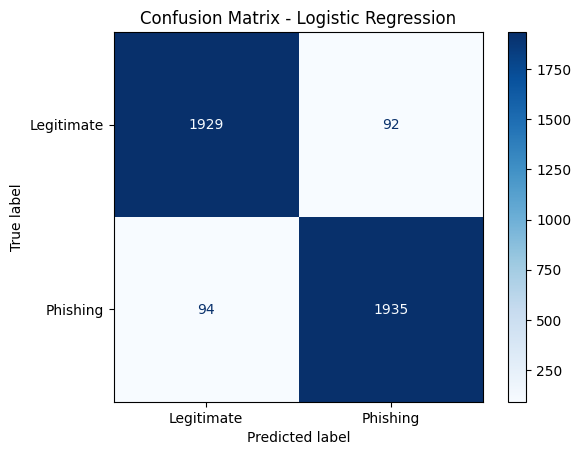

In [93]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Interpretation of Results

The baseline Logistic Regression model provides an initial indication of how effectively phishing emails can be separated from legitimate emails using TF-IDF features.

- **Precision** measures how many emails predicted as phishing were actually phishing.
- **Recall** measures how many actual phishing emails were correctly detected.
- **F1-score** balances precision and recall into a single measure.
- **Confusion matrix** shows the number of correct and incorrect predictions for each class.

In phishing detection, recall is particularly important because low recall means that phishing emails may pass through the system undetected. However, precision is also important because excessive false positives may reduce trust in the system by incorrectly flagging legitimate emails. 

The confusion matrix shows that the model performs well across both classes, with 1929 legitimate emails and 1935 phishing emails correctly classified. The number of false positives (92) and false negatives (94) is low and nearly balanced, indicating that the model does not favour one class over the other.

However, false negatives are particularly important in phishing detection, as they represent malicious emails that go undetected. While the model achieves strong overall performance, reducing false negatives would be a priority in a real-world deployment to improve security.

## Step 6: Save Baseline Model

The trained Logistic Regression model and TF-IDF vectorizer are saved so they can be reused later without retraining. This supports reproducibility and deployment.

In [94]:
import joblib

In [95]:
joblib.dump(log_reg_model, "../saved_models/logistic_regression_model.pkl")
joblib.dump(tfidf_vectorizer, "../saved_models/tfidf_vectorizer.pkl")

['../saved_models/tfidf_vectorizer.pkl']

## Step 8: Error Analysis

To better understand the behaviour of the baseline model, an error analysis is performed. This involves examining incorrect predictions to identify patterns and weaknesses in the classifier.

Particular attention is given to:
- False Positives: legitimate emails incorrectly classified as phishing
- False Negatives: phishing emails incorrectly classified as legitimate

False negatives are especially important in phishing detection, as they represent missed attacks.

The analysis also considers prediction confidence to identify cases where the model is highly confident but incorrect.

In [96]:
analysis_df = pd.DataFrame({
    "text": X_test,
    "true_label": y_test,
    "pred_label": y_pred,
    "phishing_probability": y_prob
}).reset_index(drop=True)

analysis_df.head()

,text,true_label,pred_label,phishing_probability
0,the total 2nd order up to and including july n...,0,0,0.234533
1,"i relpied to mom already, but thought you woul...",0,0,0.007015
2,-------------------------------------- -------...,1,1,0.987959
3,greg is the coo of enron networks. his e-mail ...,0,0,0.009913
4,from: mr. williams kanga. tel: numtoken - numt...,1,1,0.989538


### Identify Misclassifications

The dataset is filtered to extract incorrectly classified examples. 

Conclusion - The findings suggest that while the model effectively captures common phishing cues, it struggles with subtle or context-dependent cases, indicating an opportunity for improvement using more advanced models or contextual embeddings.

In [97]:
# False Positives: Legitimate predicted as phishing
false_positives = analysis_df[
    (analysis_df["true_label"] == 0) & (analysis_df["pred_label"] == 1)
]

# False Negatives: Phishing predicted as legitimate
false_negatives = analysis_df[
    (analysis_df["true_label"] == 1) & (analysis_df["pred_label"] == 0)
]

print("Number of False Positives:", len(false_positives))
print("Number of False Negatives:", len(false_negatives))

Number of False Positives: 92
Number of False Negatives: 94


### Analyse False Negatives

False negatives represent phishing emails that were incorrectly classified as legitimate. These cases are critical because they indicate potential security failures where malicious emails could bypass detection.

Examining these examples helps identify patterns that the model fails to capture.

Analysis revealed that many false negatives contained less obvious phishing indicators and resembled normal conversational or business emails, making them harder for the model to detect.

In [98]:
false_negatives_sorted = false_negatives.sort_values(by="phishing_probability")

false_negatives_sorted[["text", "phishing_probability"]].head(5)

,text,phishing_probability
978,phillip keith attached is the first draw reque...,0.139602
1893,hi sara- i am at home today.if you get a chanc...,0.149239
2842,the oil sector is going crazy. this is our wee...,0.150400
1483,.monkey.org paymntstub_schedule for today frid...,0.151928
2549,jeff--i have a new e mail address: emailtoken ...,0.163498


### Analyse False Positives

False positives represent legitimate emails incorrectly classified as phishing. These errors may reduce user trust in the system if too many normal emails are flagged as suspicious.

Understanding these cases helps identify overly sensitive patterns learned by the model.

False positives often included legitimate emails with promotional or urgent language, which the model associated with phishing patterns.

In [99]:
false_positives_sorted = false_positives.sort_values(by="phishing_probability", ascending=False)

false_positives_sorted[["text", "phishing_probability"]].head(5)

,text,phishing_probability
2596,pre-selected nextcard visa! as low as numtoken...,0.984498
3729,spend less on pc accessories more! radeon tm n...,0.980617
2480,new year. new releases. save up to numtoken ! ...,0.968111
1474,wicked halloween greetings only at egreetings....,0.955961
2218,"our best sale. and free shipping, too. our bes...",0.948678


### High-Confidence Errors

High-confidence misclassifications occur when the model makes incorrect predictions with strong certainty. These cases are particularly important because they indicate overconfidence in incorrect patterns.

Such errors highlight limitations in the feature representation and model assumptions. 

High-confidence error analysis revealed that the model produced 12 high-confidence false positives and no high-confidence false negatives. This indicates that while the model occasionally misclassifies legitimate emails as phishing with strong confidence, it does not confidently misclassify phishing emails as legitimate.

Inspection of high-confidence false positives showed that these emails often contained promotional or marketing language, such as offers, discounts, or urgency cues. These patterns closely resemble common phishing characteristics, leading the model to overgeneralise.

The absence of high-confidence false negatives suggests that the model is relatively cautious when handling potential phishing emails, which is desirable in a security context. However, the presence of high-confidence false positives highlights a limitation of the TF-IDF representation, which lacks deeper contextual understanding.

This suggests that more advanced models, such as transformer-based approaches, may be required to better distinguish between legitimate promotional content and malicious phishing attempts.

In [101]:
# High-confidence false positives
high_fp = false_positives[false_positives["phishing_probability"] > 0.9]

# High-confidence false negatives
high_fn = false_negatives[false_negatives["phishing_probability"] < 0.1]

print("High-confidence False Positives:", len(high_fp))
print("High-confidence False Negatives:", len(high_fn))

High-confidence False Positives: 12
High-confidence False Negatives: 0


In [102]:
high_fp[["text", "phishing_probability"]].head(3)

,text,phishing_probability
819,free software gift! image free software gift! ...,0.908000
1474,wicked halloween greetings only at egreetings....,0.955961
2136,nfl playoff betting special! ! ! ! ! ! ! janua...,0.911471


In [105]:
high_fn[["text", "phishing_probability"]].head(3)

,text,phishing_probability
